
### Complete workflow example:
1. Load MODFLOW water content data
2. Convert to resistivity model using petrophysical relationships
3. Perform forward ERT simulation
4. Conduct inversion to recover the resistivity model


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics import ert
from pygimli.physics import TravelTimeManager
import pygimli.physics.traveltime as tt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Setup package path for development
try:
    # For regular Python scripts
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # For Jupyter notebooks
    current_dir = os.getcwd()

# Add the parent directory to Python path
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Import PyHydroGeophysX modules
from PyHydroGeophysX.core.interpolation import ProfileInterpolator, create_surface_lines
from PyHydroGeophysX.core.mesh_utils import MeshCreator
from PyHydroGeophysX.petrophysics.resistivity_models import WS_Model
from PyHydroGeophysX.petrophysics.velocity_models import HertzMindlinModel, DEMModel
from PyHydroGeophysX.forward.ert_forward import ERTForwardModeling
from PyHydroGeophysX.inversion.ert_inversion import ERTInversion
from PyHydroGeophysX.Hydro_modular import hydro_to_ert


In [3]:
output_dir = "results/workflow_example"
os.makedirs(output_dir, exist_ok=True)

# Step by Step approach

## Loading domain information...

In [4]:
# These would be your actual data files
data_dir = "data/"
modflow_dir = os.path.join(data_dir, "modflow")

# Load domain information from files
# (Replace with your actual file paths)
idomain = np.loadtxt(os.path.join(data_dir, "id.txt"))
top = np.loadtxt(os.path.join(data_dir, "top.txt"))
porosity = np.load(os.path.join(data_dir, "Porosity.npy"))

## Loading MODFLOW water content data..

In [5]:
# Step 2: Exmaple of loading MODFLOW water content data


# Note that to save the loading time, we only use a low resoluation model load for the example
# In a real-world application, you would load the full resolution data
# here we will load the npy file for the water content to save time

# Load the water content from a .npy file for demonstration purposes

Water_Content = np.load(os.path.join(data_dir, "Watercontent.npy"))

water_content = Water_Content[50]
print(water_content.shape)

(14, 194, 157)


## Set up profile for 2D section

In [6]:
# Step 3: Set up profile for 2D section
print("Step 3: Setting up profile...")

# Define profile endpoints
point1 = [115, 70]  # [col, row]
point2 = [95, 180]  # [col, row]

# Initialize profile interpolator
interpolator = ProfileInterpolator(
    point1=point1,
    point2=point2,
    surface_data=top,
    origin_x=569156.0,
    origin_y=4842444.0,
    pixel_width=1.0,
    pixel_height=-1.0,
    num_points = 400
)

Step 3: Setting up profile...


## Interpolating data to profile

In [7]:
# Step 4: Interpolate data to profile

# Interpolate water content to profile
water_content_profile = interpolator.interpolate_3d_data(water_content)

# Interpolate porosity to profile
porosity_profile = interpolator.interpolate_3d_data(porosity)

## Creating mesh

In [8]:

# Load structure layers
bot = np.load(os.path.join(data_dir, "bot.npy"))

# Process layers to get structure
structure = interpolator.interpolate_layer_data([top] + bot.tolist())

# Create surface lines
# Indicate the layer for the structure regolith, fractured bedrock and fresh bedrock
top_idx=int(0)
mid_idx=int(4)
bot_idx=int(13)
surface, line1, line2 = create_surface_lines(
    L_profile=interpolator.L_profile,
    structure=structure,
    top_idx=top_idx,
    mid_idx=mid_idx,
    bot_idx=bot_idx
)

# Create mesh
mesh_creator = MeshCreator(quality=32)
mesh, geom = mesh_creator.create_from_layers(
    surface=surface,
    layers=[line1, line2],
    bottom_depth= np.min(line2[:,1])-10 #50.0
)

# Save mesh
mesh.save(os.path.join(output_dir, "mesh.bms"))

1

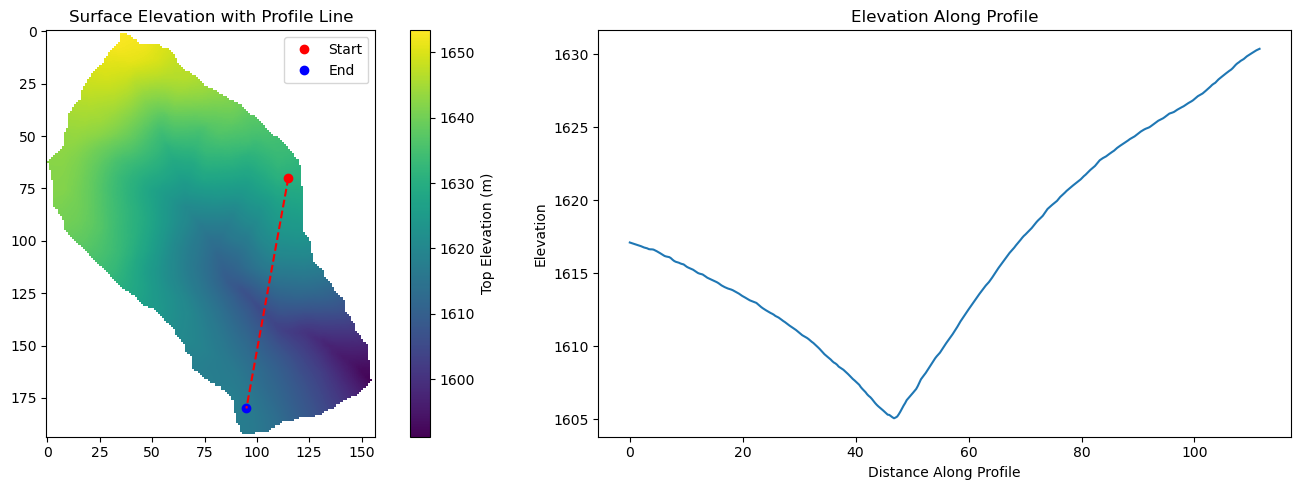

In [9]:
# Visualize the result
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
top[idomain==0] = np.nan  # Mask out the inactive cells in the top layer
# Plot the surface and profile line
plt.subplot(121)
plt.imshow(top)
plt.colorbar(label='Top Elevation (m)')
plt.plot(point1[0], point1[1], 'ro', label='Start')
plt.plot(point2[0], point2[1], 'bo', label='End')
plt.plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--')
plt.legend()
plt.title('Surface Elevation with Profile Line')

# Plot the profile coordinates
plt.subplot(122)
plt.plot(surface[:,0], surface[:,1])
plt.title('Elevation Along Profile')
plt.xlabel('Distance Along Profile')
plt.ylabel('Elevation')

plt.tight_layout()
plt.show()

## Interpolating data to mesh

In [10]:
# Step 6: Interpolate data to mesh


ID1 = porosity_profile.copy()
ID1[:mid_idx] = 0 #regolith
ID1[mid_idx:bot_idx] = 3 # fractured bedrock
ID1[bot_idx:] = 2 # fresh bedrock

# Get mesh centers and markers
mesh_centers = np.array(mesh.cellCenters())
mesh_markers = np.array(mesh.cellMarkers())


# marker labels for the layers
marker_labels = [0, 3, 2] # top. mid, bottom layers (example values)
# assign the values for the regolith and fractured bedrock
ID1 = porosity_profile.copy()
ID1[:mid_idx] = marker_labels[0] #regolith
ID1[mid_idx:] = marker_labels[1] # fractured bedrock


# Get mesh centers and markers
mesh_centers = np.array(mesh.cellCenters())
mesh_markers = np.array(mesh.cellMarkers())
porosity_mesh = np.zeros_like(mesh_markers, dtype=float)
wc_mesh = np.zeros_like(mesh_markers, dtype=float)
for i in range(len(marker_labels)):
    if i == 2:
        # assign the values for the fresh bedrock, since fresh bedrock is no flux boundary and assume the homogeneous as the last layer
        ID1[bot_idx] = marker_labels[2] # fractured bedrock # fresh bedrock
    # Interpolate porosity to mesh
    porosity_temp = interpolator.interpolate_to_mesh(
        property_values=porosity_profile,
        depth_values=structure,
        mesh_x=mesh_centers[:, 0],
        mesh_y=mesh_centers[:, 1],
        mesh_markers=mesh_markers,
        ID=ID1, # Use ID1 to indicate the layers for interpolation
        layer_markers = [marker_labels[i]],

    )

    porosity_mesh[mesh_markers==marker_labels[i]] = porosity_temp[mesh_markers==marker_labels[i]]

    # Interpolate water content to mesh
    wc_temp = interpolator.interpolate_to_mesh(
        property_values=water_content_profile,
        depth_values=structure,
        mesh_x=mesh_centers[:, 0],
        mesh_y=mesh_centers[:, 1],
        mesh_markers=mesh_markers,
        ID=ID1, # Use ID1 to indicate the layers for interpolation
        layer_markers = [marker_labels[i]],
    )
    wc_mesh[mesh_markers==marker_labels[i]] = wc_temp[mesh_markers==marker_labels[i]]




saturation = wc_mesh / porosity_mesh

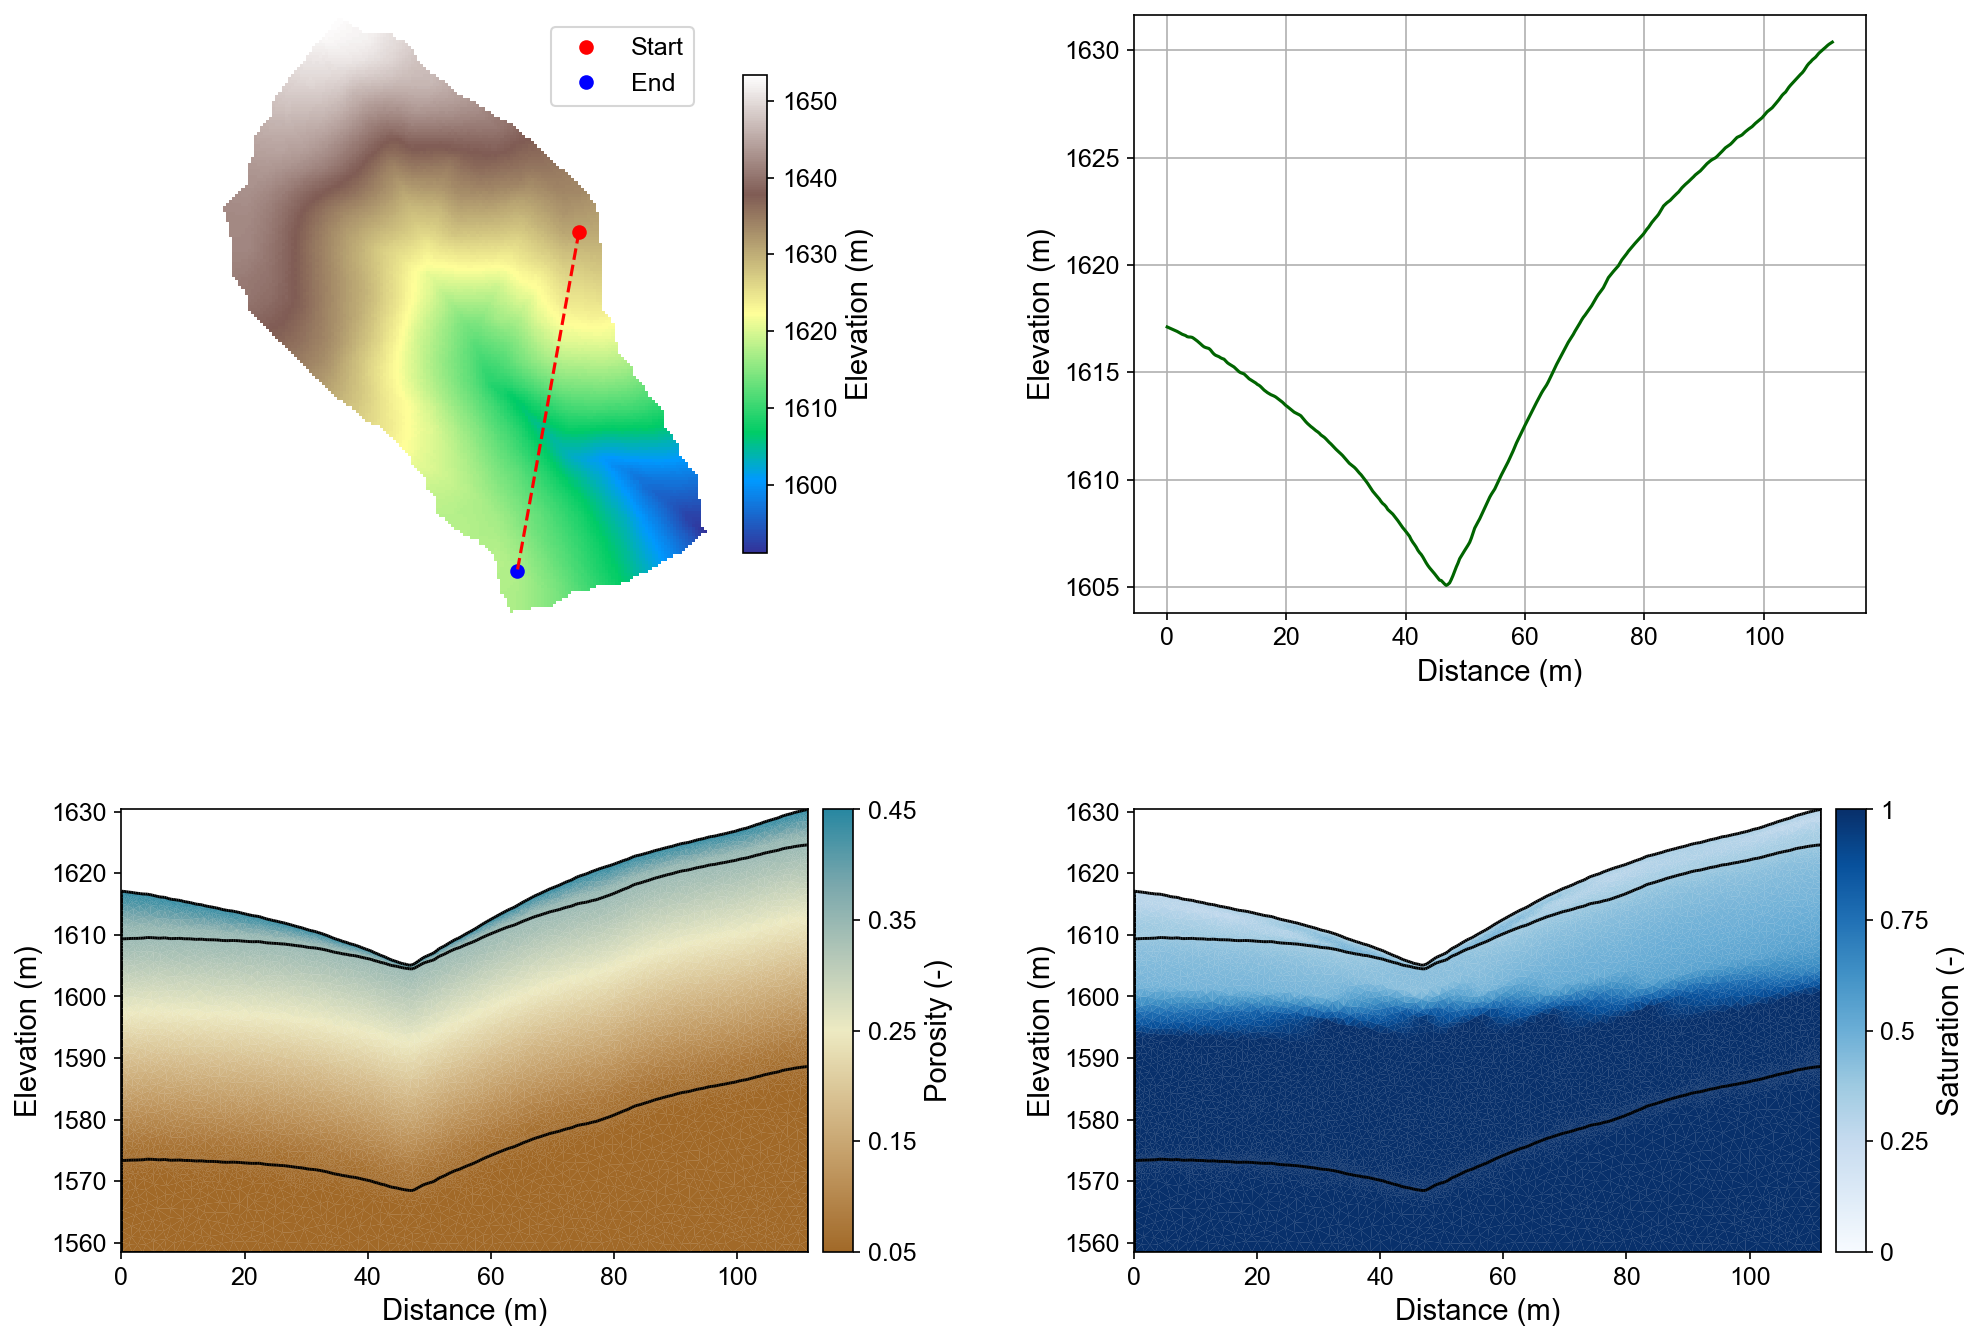

In [41]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pygimli as pg
from palettable.cartocolors.diverging import Earth_7

# Font settings for publication
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['figure.dpi'] = 150

# Preprocessing
top_masked = np.copy(top)
top_masked[idomain == 0] = np.nan
saturation = wc_mesh / porosity_mesh
ctcolor = Earth_7.mpl_colormap

# Create 2x2 figure
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# --- Top Left: Surface elevation map ---
im0 = axs[0, 0].imshow(top_masked, origin='lower', cmap='terrain')
axs[0, 0].invert_yaxis()

# Plot profile line and points
axs[0, 0].plot(point1[0], point1[1], 'ro', label='Start')
axs[0, 0].plot(point2[0], point2[1], 'bo', label='End')
axs[0, 0].plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--')

# Remove ticks and axis borders
axs[0, 0].set_xticks([])
axs[0, 0].set_yticks([])
for spine in axs[0, 0].spines.values():
    spine.set_visible(False)

# Title and colorbar

cbar0 = fig.colorbar(im0, ax=axs[0, 0], orientation='vertical', shrink=0.8)
cbar0.set_label('Elevation (m)')
axs[0, 0].legend(loc='upper right')

# --- Top Right: Elevation profile ---
axs[0, 1].plot(surface[:, 0], surface[:, 1], color='darkgreen')

axs[0, 1].set_xlabel('Distance (m)')
axs[0, 1].set_ylabel('Elevation (m)')
axs[0, 1].grid(True)

# --- Bottom Left: Porosity mesh ---
pg.show(mesh, porosity_mesh,
        ax=axs[1, 0], orientation="vertical", cMap=ctcolor,
        cMin=0.05, cMax=0.45,
        xlabel="Distance (m)", ylabel="Elevation (m)",
        label='Porosity (-)', showColorBar=True)

# --- Bottom Right: Saturation mesh ---
pg.show(mesh, saturation,
        ax=axs[1, 1], orientation="vertical", cMap='Blues',
        cMin=0, cMax=1,
        xlabel="Distance (m)", ylabel="Elevation (m)",
        label='Saturation (-)', showColorBar=True)

# Layout adjustment
plt.tight_layout(pad=3)
plt.savefig(os.path.join(output_dir, "topography_and_properties.tiff"), dpi=300)


In [12]:
print("Water Content min/max:", np.min(wc_mesh), np.max(wc_mesh))
print("Saturation min/max:", np.min(saturation), np.max(saturation))


Water Content min/max: 0.04999999999999998 0.27217677063432144
Saturation min/max: 0.26787257055093544 1.0


## Calculating saturation

In [14]:
# Ensure porosity is not zero to avoid division by zero
saturation = np.clip(wc_mesh / porosity_mesh, 0.0, 1.0)


## Converting to resistivity

In [ ]:
# Convert to resistivity using petrophysical model

marker_labels = [0, 3, 2] # top. mid, bottom layers (example values)
sigma_w = [1/20,1/20,1/20]  # Conductivity of water in S/m (example value)
m = [1.2, 1.8, 1.9] # Cementation exponent for each layer (example values)
n = [2.2, 1.8, 2.5] # Saturation exponent for each layer (example values)
sigma_s = [1/100, 0, 0] # Saturated resistivity of the surface conductivity see Chen & Niu, (2022) for each layer (example values)
# Convert water content back to resistivity

res_models = np.zeros_like(wc_mesh)  # Initialize an array for resistivity values

mask = (mesh_markers == marker_labels[0])
top_res = WS_Model(
    saturation[mask],                  # Water content values for this layer
    porosity_mesh[mask],            # Porosity values for this layer
    sigma_w[0],                # Conductivity of water in S/m
    m[0],                    # Cementation exponent for this layer
    n[0],                    # Saturation exponent for this layer
    sigma_s[0] # Use a scalar value
)
res_models[mask] = top_res

mask = (mesh_markers == marker_labels[1])
mid_res = WS_Model(
    saturation[mask],                  # Water content values for this layer
    porosity_mesh[mask],            # Porosity values for this layer
    sigma_w[1],                # Conductivity of water in S/m
    m[1],                    # Cementation exponent for this layer
    n[1],                    # Saturation exponent for this layer
    sigma_s[1] # Use a scalar value
)
res_models[mask] = mid_res


mask = (mesh_markers == marker_labels[2])
bot_res = WS_Model(
    saturation[mask],                  # Water content values for this layer
    porosity_mesh[mask],            # Porosity values for this layer
    sigma_w[2],                # Conductivity of water in S/m
    m[2],                    # Cementation exponent for this layer
    n[2],                    # Saturation exponent for this layer
    sigma_s[2] # Use a scalar value
)
res_models[mask] = bot_res


In [28]:
print(np.min(top_res), np.max(top_res))
print(np.min(mid_res), np.max(mid_res))
print(np.min(bot_res), np.max(bot_res))

247.17175118576233 595.0794853668683
208.11246499732235 4394.242173224475
5929.075592855579 5929.075592855585


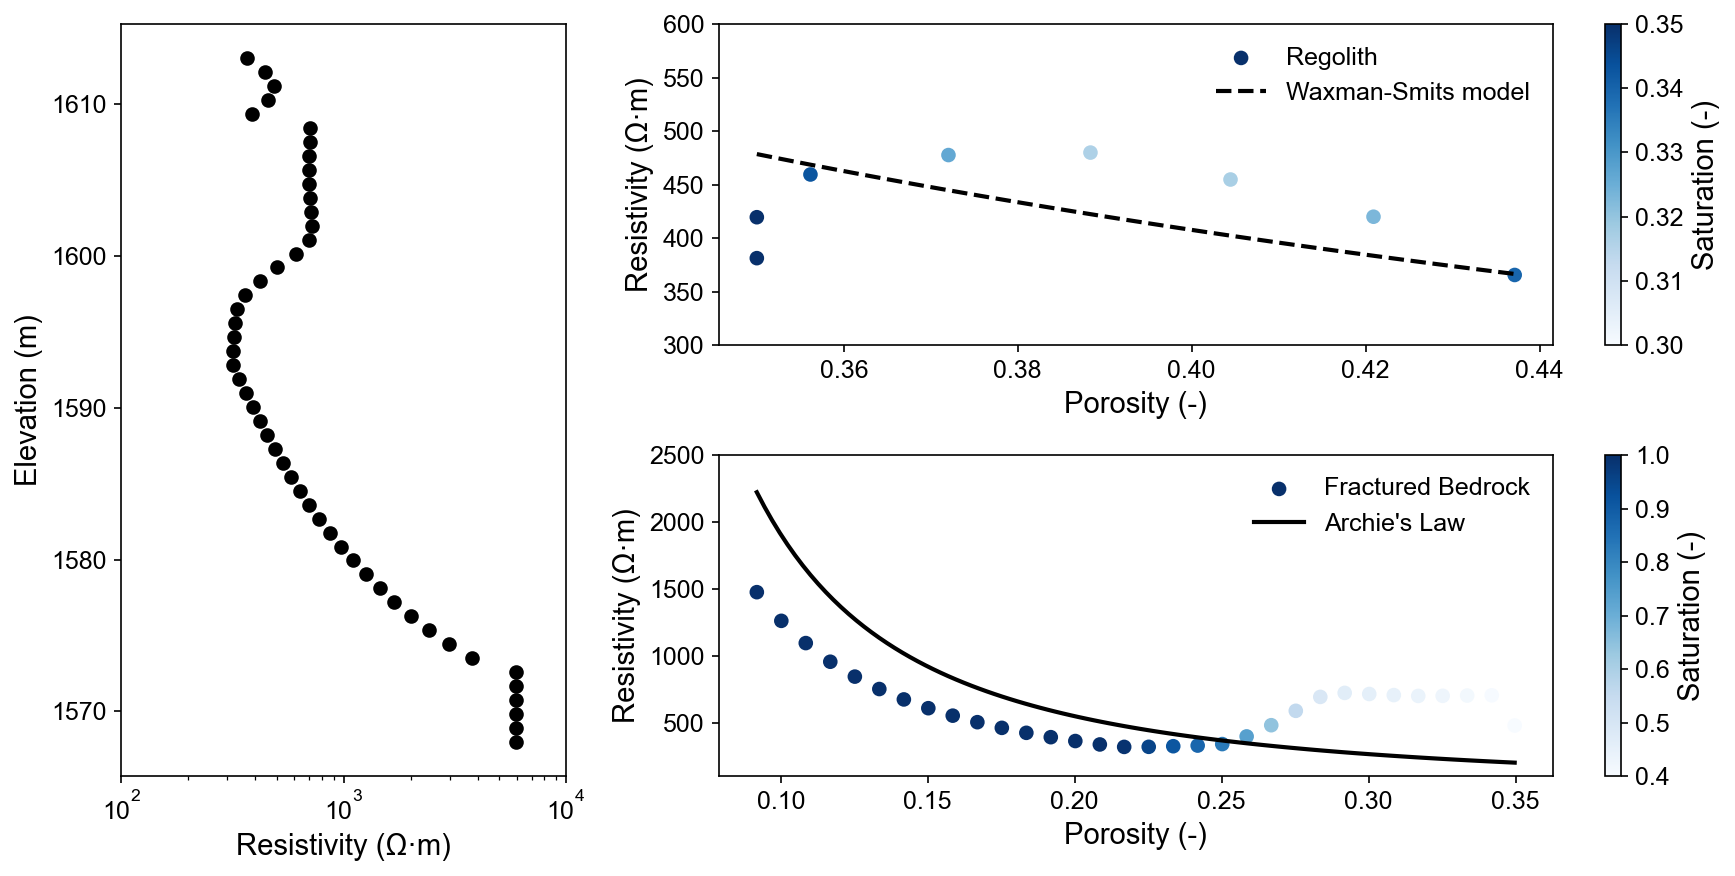

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

plt.figure(figsize=(12, 6))

# First subplot - narrower left side (spans both rows, 1 column)
plt.subplot2grid((2, 3), (0, 0), rowspan=2, colspan=1)
x1, y1 = np.mgrid[20:21:1j, 1568:1613:50j]
res = griddata(mesh_centers[:,0:2], res_models, (x1, y1), method='linear')
po = griddata(mesh_centers[:,0:2], porosity_mesh, (x1, y1), method='linear')
sat = griddata(mesh_centers[:,0:2], saturation, (x1, y1), method='linear')
wc = griddata(mesh_centers[:,0:2], wc_mesh, (x1, y1), method='linear')
# Plotting the first interpolation
plt.scatter(res.ravel(), y1.ravel(),c='k')
plt.xlabel('Resistivity (Ω·m)')
plt.ylabel('Elevation (m)')
plt.xscale('log')
plt.xlim([100,10000])
# Second subplot - larger top right position (spans 2 columns)
plt.subplot2grid((2, 3), (0, 1), colspan=2)
# First interpolation for the main plot
x1, y1 = np.mgrid[20:21:1j, 1609.2:1613:8j]
res = griddata(mesh_centers[:,0:2], res_models, (x1, y1), method='linear')
po = griddata(mesh_centers[:,0:2], porosity_mesh, (x1, y1), method='linear')
sat = griddata(mesh_centers[:,0:2], saturation, (x1, y1), method='linear')
wc = griddata(mesh_centers[:,0:2], wc_mesh, (x1, y1), method='linear')
# Plotting the first interpolation
plt.scatter(po.ravel(), res.ravel(), c=sat, vmin=0.3, vmax=0.35, cmap='Blues',label='Regolith')
plt.colorbar(label='Saturation (-)')
plt.xlabel('Porosity (-)')
plt.ylabel('Resistivity (Ω·m)')
res0 = WS_Model(
    np.ones(100)*np.mean(sat),                  # Water content values for this layer
    np.linspace(np.nanmin(po.ravel()), np.nanmax(po.ravel()), 100),            # Porosity values for this layer
    sigma_w[0],                # Conductivity of water in S/m
    m[0],                    # Cementation exponent for this layer
    n[0],                    # Saturation exponent for this layer
    sigma_s[0] # Use a scalar value
)

plt.plot(np.linspace(np.nanmin(po.ravel()), np.nanmax(po.ravel()), 100), res0, 'k--', lw=2,label = "Waxman-Smits model")
plt.ylim([300,600])
plt.legend(frameon=False)
# Third subplot - larger bottom right position (spans 2 columns)
plt.subplot2grid((2, 3), (1, 1), colspan=2)


# First interpolation for the main plot
x1, y1 = np.mgrid[20:21:1j, 1578:1609:32j]
res = griddata(mesh_centers[:,0:2], res_models, (x1, y1), method='linear')
po = griddata(mesh_centers[:,0:2], porosity_mesh, (x1, y1), method='linear')
sat = griddata(mesh_centers[:,0:2], saturation, (x1, y1), method='linear')
wc = griddata(mesh_centers[:,0:2], wc_mesh, (x1, y1), method='linear')
# Plotting the first interpolation
plt.scatter(po.ravel(), res.ravel(), c=sat, cmap='Blues', vmin=0.4, vmax=1,label='Fractured Bedrock')
plt.colorbar(label='Saturation (-)')
plt.xlabel('Porosity (-)')
plt.ylabel('Resistivity (Ω·m)')
res0 = WS_Model(
    np.ones(100)*np.nanmean(sat),                  # Water content values for this layer
    np.linspace(np.nanmin(po.ravel()), np.nanmax(po.ravel()), 100),            # Porosity values for this layer
    sigma_w[1],                # Conductivity of water in S/m
    m[1],                    # Cementation exponent for this layer
    n[1],                    # Saturation exponent for this layer
    sigma_s[1] # Use a scalar value
)

plt.plot(np.linspace(np.nanmin(po.ravel()), np.nanmax(po.ravel()), 100), res0, 'k', lw=2,label = "Archie's Law")
plt.legend(frameon=False)
plt.ylim([100,2500])
# plt.yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "resistivity_porosity_saturation.tiff"), dpi=300)

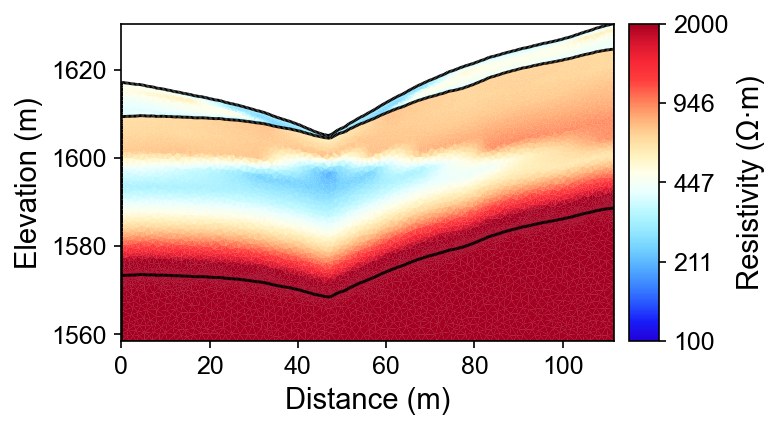

In [32]:
# plot the resistivity model
from palettable.lightbartlein.diverging import BlueDarkRed18_18
fixed_cmap = BlueDarkRed18_18.mpl_colormap



# --- Create figure with 1 row, 2 columns ---
fig, axs = plt.subplots(1, 1, figsize=(6, 4))

# --- Left: Resistivity with log scale ---
pg.show(mesh, res_models, ax=axs, orientation="vertical",
        cMap=fixed_cmap, logScale=True, showColorBar=True,
        xlabel="Distance (m)", ylabel="Elevation (m)",
        label='Resistivity (Ω·m)', cMin=100, cMax=2000)


# --- Final layout ---
plt.tight_layout(pad=3)

plt.savefig(os.path.join(output_dir, "res_model.tiff"), dpi=300)

## ERT forward modeling simulation

In [35]:
xpos = np.linspace(15,15+72 - 1,72)
ypos = np.interp(xpos,interpolator.L_profile,interpolator.surface_profile)
pos = np.hstack((xpos.reshape(-1,1),ypos.reshape(-1,1)))

schemeert = ert.createData(elecs=pos,schemeName='wa')

# Step 10: Forward modeling to create synthetic ERT data

mesh.setCellMarkers(np.ones(mesh.cellCount())*2)
grid = pg.meshtools.appendTriangleBoundary(mesh, marker=1,
                                          xbound=100, ybound=100)

fwd_operator = ERTForwardModeling(mesh=grid, data=schemeert)


synth_data = schemeert.copy()
fob = ert.ERTModelling()
fob.setData(schemeert)
fob.setMesh(grid)
dr = fob.response(res_models)

dr *= 1. + pg.randn(dr.size()) * 0.05
ert_manager = ert.ERTManager(synth_data)
synth_data['rhoa'] = dr
synth_data['err'] = ert_manager.estimateError(synth_data, absoluteUError=0.0, relativeError=0.05)
#ert.showData(synth_data,  logscale=True)
synth_data.save(os.path.join(output_dir, "synthetic_data.dat"))

20/06/25 - 16:13:34 - pyGIMLi - INFO - Found 2 regions.
20/06/25 - 16:13:34 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
20/06/25 - 16:13:34 - pyGIMLi - INFO - Found 2 regions.
20/06/25 - 16:13:34 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
20/06/25 - 16:13:34 - pyGIMLi - INFO - Creating forward mesh from region infos.
20/06/25 - 16:13:34 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
20/06/25 - 16:13:35 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 39712 Cells: 78572 Boundaries: 59354


1

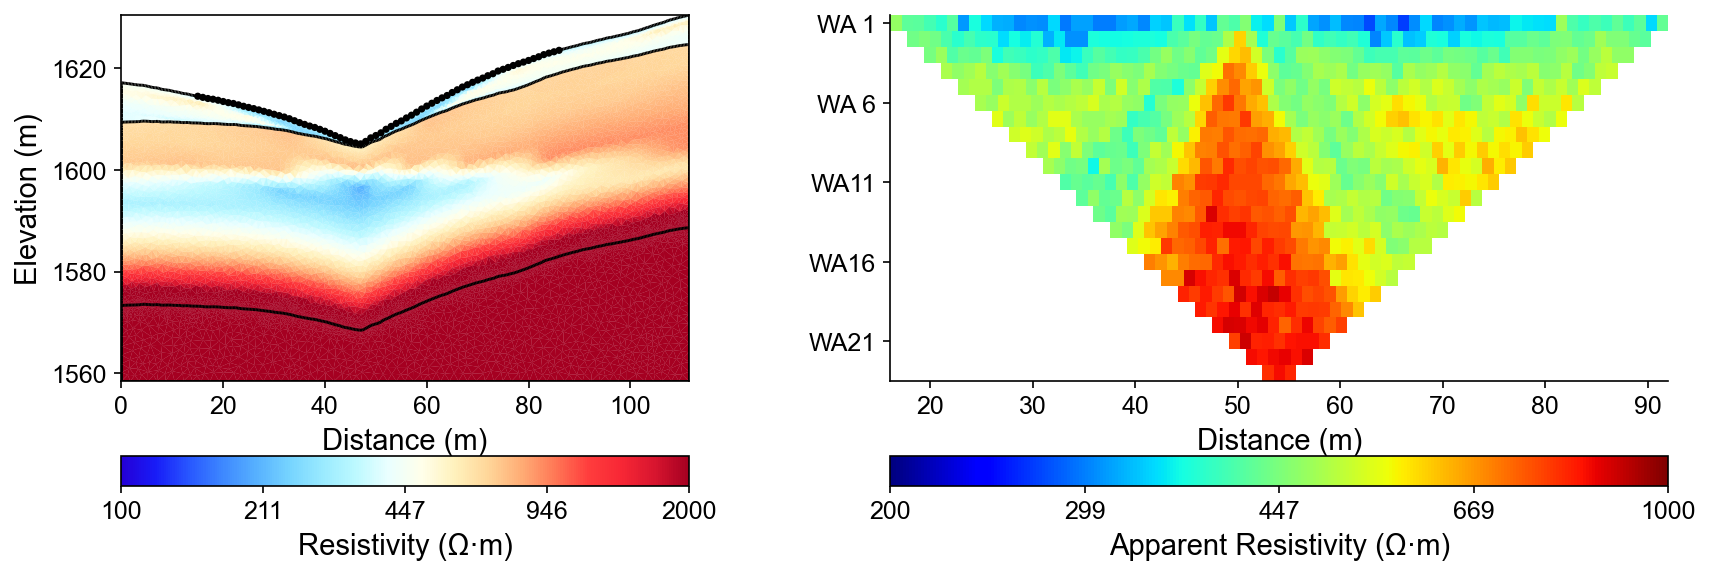

<Figure size 960x720 with 0 Axes>

In [40]:
from palettable.lightbartlein.diverging import BlueDarkRed18_18
import matplotlib.pyplot as plt

fixed_cmap = BlueDarkRed18_18.mpl_colormap

# --- Create figure with 1 row, 2 columns ---
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# --- Left subplot (121): Resistivity with log scale ---
pg.show(mesh, res_models, ax=axs[0], orientation="horizontal",
        cMap=fixed_cmap, logScale=True, showColorBar=True,
        xlabel="Distance (m)", ylabel="Elevation (m)", 
        label='Resistivity (Ω·m)', cMin=100, cMax=2000)
pg.viewer.mpl.drawSensors(axs[0], schemeert.sensors(), diam=1,
                         facecolor='black', edgecolor='black')
# --- Right subplot (122): ERT data ---
ax_ert, cbar_default = ert.showData(synth_data, logscale=False, ax=axs[1], cMin=200, cMax=1000, cMap='jet', label='Apparent Resistivity (Ω·m)'
                                    )

axs[1].set_xlabel("Distance (m)")
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

# Optional: Adjust spacing between subplots
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(output_dir, "res_model_and_synth_data.tiff"), dpi=300)

Velocity range: 476.8782035146678 5264.711328313164


C:\Users\HChen8\AppData\Local\Temp\ipykernel_55724\593002678.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


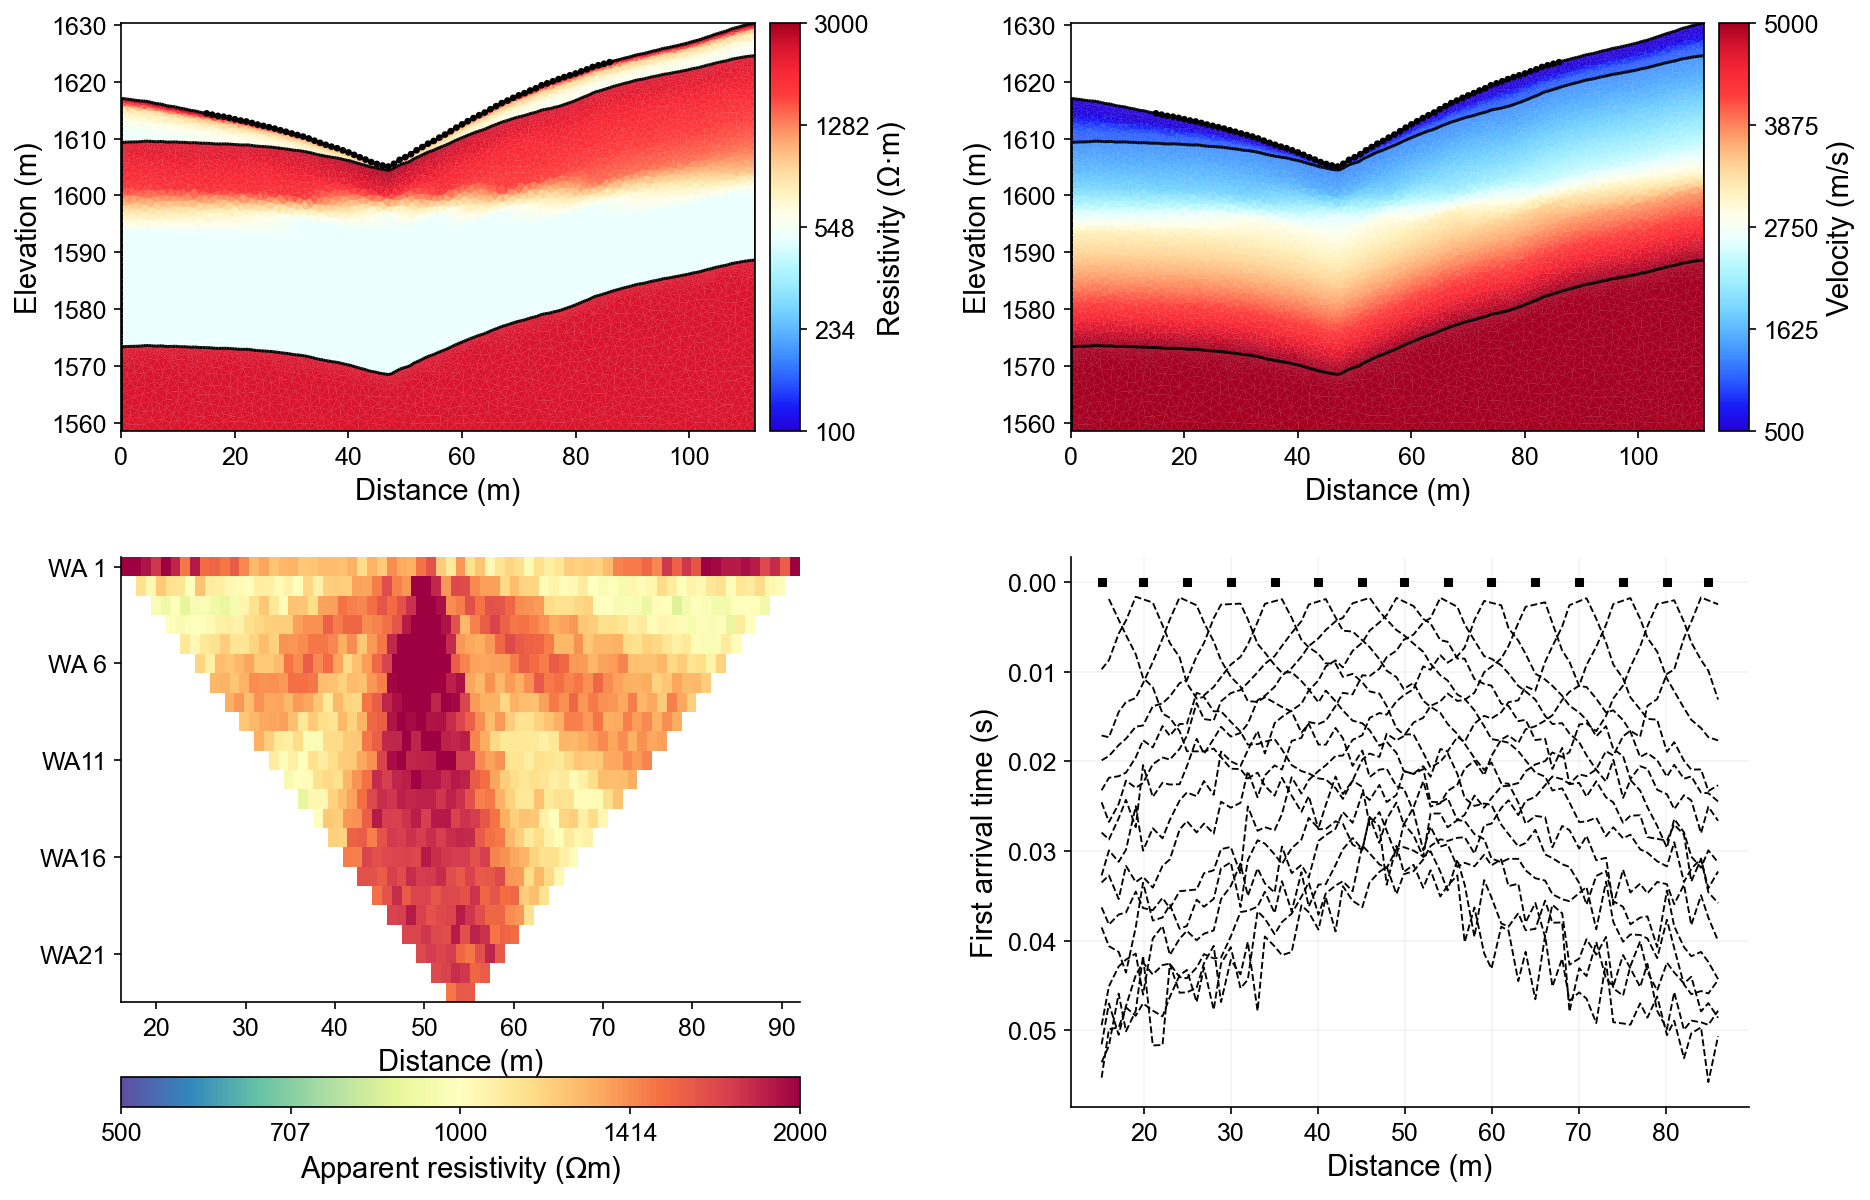

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg

# Assume mesh, res_models, velocity_mesh, fixed_cmap, synth_data, datasrt, ert, drawFirstPicks are already defined

# Create 2×2 axes
fig, axs = plt.subplots(2, 2, figsize=(14, 10),
                        gridspec_kw={'hspace': 0.1, 'wspace': 0.4})

# Flatten for easy indexing
ax1, ax2, ax3, ax4 = axs.flatten()

# --- Top left: Resistivity (log scale) ---
pg.show(mesh, res_models, ax=ax1, orientation="vertical",
        cMap=fixed_cmap, logScale=True, showColorBar=True,
        xlabel="Distance (m)", ylabel="Elevation (m)",
        label='Resistivity (Ω·m)', cMin=100, cMax=3000)
# Invert y (so elevation decreases downward)
pg.viewer.mpl.drawSensors(ax1, schemeert.sensors(), diam=0.8,
                         facecolor='black', edgecolor='black')


# --- Top right: P-wave velocity (fixed scale) ---
pg.show(mesh, velocity_mesh, ax=ax2, orientation="vertical",
        cMap=fixed_cmap, cMin=500, cMax=5000, showColorBar=True,
        xlabel="Distance (m)", ylabel="Elevation (m)",
        label='Velocity (m/s)')
pg.viewer.mpl.drawSensors(ax2, schemeert.sensors(), diam=0.8,
                         facecolor='black', edgecolor='black')


# Print range for debugging
print("Velocity range:", np.min(velocity_mesh), np.max(velocity_mesh))

# --- Bottom left: Synthetic ERT data ---
ert.showData(synth_data, logscale=True, ax=ax3, cMin=500, cMax=2000,cmap='jet')

ax3.set_xlabel("Distance (m)")
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- Bottom right: First-break picks ---
drawFirstPicks(ax=ax4, data=datasrt)

ax4.set_xlabel("Distance (m)")
ax4.set_ylabel("First arrival time (s)")
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "ert_seismic.tiff"), dpi=300)


In [ ]:
# Step 11: Run ERT inversion on synthetic data

## using my code to the inversion
print("Step 11: Running ERT inversion...")

# Create ERT inversion object
inversion = ERTInversion(
    data_file=os.path.join(output_dir, "synthetic_data.dat"),
    lambda_val=10.0,
    method="cgls",
    use_gpu=True,
    max_iterations=10,
    lambda_rate= 1.0
)
inversion_result = inversion.run()

08/06/25 - 15:39:44 - pyGIMLi - INFO - Found 2 regions.
08/06/25 - 15:39:44 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
08/06/25 - 15:39:44 - pyGIMLi - INFO - Found 2 regions.
08/06/25 - 15:39:44 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
08/06/25 - 15:39:44 - pyGIMLi - INFO - Creating forward mesh from region infos.
08/06/25 - 15:39:44 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


Step 11: Running ERT inversion...


08/06/25 - 15:39:44 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 4193 Cells: 7984 Boundaries: 6188


-------------------Iteration: 0 ---------------------------
chi2: [[11.7851317]]
dPhi: 1.0
-------------------Iteration: 1 ---------------------------
chi2: [[3.70433155]]
dPhi: [[0.68567754]]
-------------------Iteration: 2 ---------------------------
chi2: [[3.54606013]]
dPhi: [[0.04272604]]
-------------------Iteration: 3 ---------------------------
chi2: [[0.8824812]]
dPhi: [[0.75113755]]
End of inversion


In [ ]:
## Using Pygimili default to the inversion
mgr = ert.ERTManager(os.path.join(output_dir, "synthetic_data.dat"))
inv = mgr.invert(lam=10, verbose=True,quality=34)

08/06/25 - 15:40:03 - pyGIMLi - INFO - Found 2 regions.
08/06/25 - 15:40:03 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
08/06/25 - 15:40:03 - pyGIMLi - INFO - Found 2 regions.
08/06/25 - 15:40:03 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
08/06/25 - 15:40:03 - pyGIMLi - INFO - Creating forward mesh from region infos.
08/06/25 - 15:40:03 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
08/06/25 - 15:40:03 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 4193 Cells: 7984 Boundaries: 6188
08/06/25 - 15:40:03 - pyGIMLi - INFO - Use median(data values)=1350.93069546834
08/06/25 - 15:40:03 - pyGIMLi - INFO - Created startmodel from forward operator: 1438, min/max=1350.930695/1350.930695
08/06/25 - 15:40:03 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000022E6DD78FE0>
Data transformation: <pgcore._pygimli_.RTransLogLU object at 0x0000022E5A271940>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x0000022E6C151710>
min/max (data): 858/2409
min/max (error): 5%/5%
min/max (start model): 1351/1351
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =   11.22
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =    3.20 (dPhi = 68.17%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =    1.28 (dPhi = 52.05%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    1.10 (dPhi = 6.87%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    1.05 (dPhi = 1.89%) lam: 10.0
###################

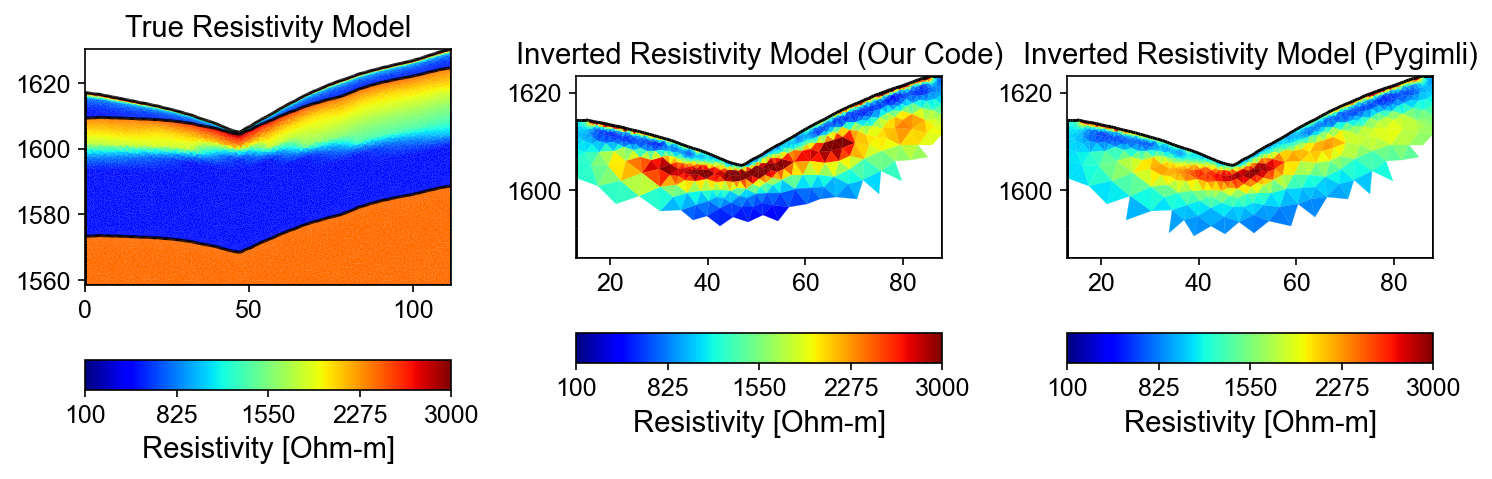

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 12))

# True resistivity model
ax1 = axes[0]
cbar1 = pg.show(mesh, res_models, ax=ax1, cMap='jet', logScale=False, 
              cMin=100, cMax=3000, label='Resistivity [Ohm-m]')
ax1.set_title("True Resistivity Model")

# Inverted model
ax2 = axes[1]
cbar2 = pg.show(inversion_result.mesh, inversion_result.final_model, ax=ax2, cMap='jet', logScale=False, 
              cMin=100, cMax=3000, label='Resistivity [Ohm-m]',coverage=inversion_result.coverage>-1)
ax2.set_title("Inverted Resistivity Model (Our Code)")

ax3 = axes[2]
cbar2 = pg.show(mgr.paraDomain, mgr.paraModel(), ax=ax3, cMap='jet', logScale=False, 
              cMin=100, cMax=3000, label='Resistivity [Ohm-m]',coverage=mgr.coverage()>-1)
ax3.set_title("Inverted Resistivity Model (Pygimli)")
# Adjust layout
plt.tight_layout()



# The inversion results are almost same from this code and Pygimli default inversion.
# the difference is that the chi2 value for stop inversion is not the same, we chose 1.5 while Pygimli is 1.0

# One step approach

## ERT one step from HM to GM

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [3. 3. 3. ... 3. 3. 3.]
 [2. 2. 2. ... 2. 2. 2.]
 [2. 2. 2. ... 2. 2. 2.]]
Resistivity range: 500.0 - 5478.379862087077 Ohm-m


08/06/25 - 15:40:37 - pyGIMLi - INFO - Found 2 regions.
08/06/25 - 15:40:37 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
08/06/25 - 15:40:37 - pyGIMLi - INFO - Found 2 regions.
08/06/25 - 15:40:37 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
08/06/25 - 15:40:37 - pyGIMLi - INFO - Creating forward mesh from region infos.
08/06/25 - 15:40:37 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
08/06/25 - 15:40:38 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 37828 Cells: 74804 Boundaries: 56528


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x23012660390>)

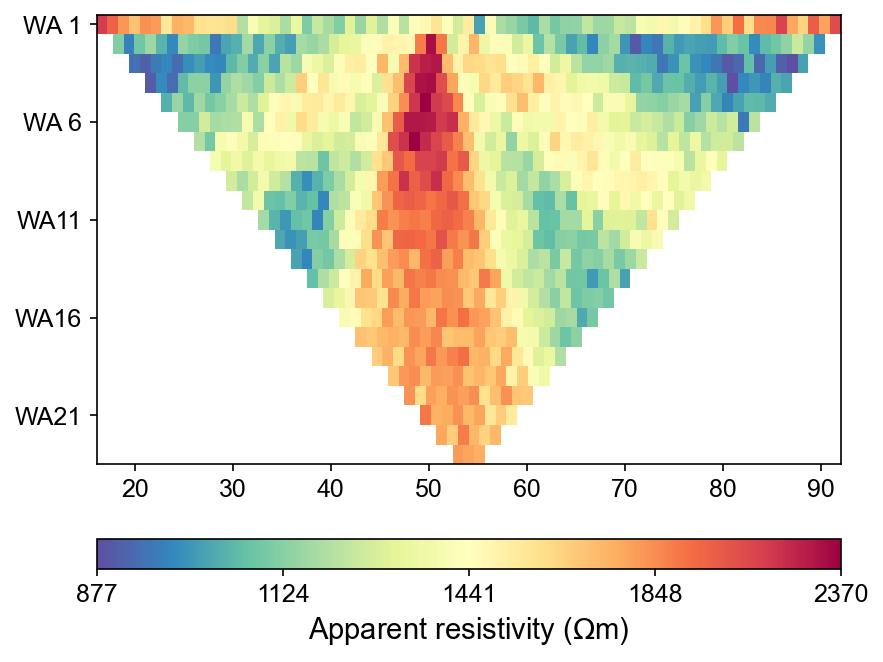

In [26]:
# Set up directories
output_dir = "results/hydro_to_ert_example"
os.makedirs(output_dir, exist_ok=True)

# Load your data
data_dir = "data/"
idomain = np.loadtxt(os.path.join(data_dir, "id.txt"))
top = np.loadtxt(os.path.join(data_dir, "top.txt"))
porosity = np.load(os.path.join(data_dir, "Porosity.npy"))
water_content = np.load(os.path.join(data_dir, "Watercontent.npy"))[5]  # Time step 50

# Set up profile
point1 = [115, 70]  
point2 = [95, 180]  

interpolator = ProfileInterpolator(
    point1=point1,
    point2=point2,
    surface_data=top,
    origin_x=569156.0,
    origin_y=4842444.0,
    pixel_width=1.0,
    pixel_height=-1.0,
    num_points=400
)

# Create mesh structure
bot = np.load(os.path.join(data_dir, "bot.npy"))
layer_idx = [0, 4, 12]  # Example indices for top, middle, and bottom layers
structure = interpolator.interpolate_layer_data([top] + bot.tolist())
surface, line1, line2 = create_surface_lines(
    L_profile=interpolator.L_profile,
    structure=structure,
    top_idx=layer_idx[0],
    mid_idx=layer_idx[1],
    bot_idx=layer_idx[2]
)

# Create mesh
mesh_creator = MeshCreator(quality=32)
mesh, geom = mesh_creator.create_from_layers(
    surface=surface,
    layers=[line1, line2],
    bottom_depth=np.min(line2[:,1])-10
)

# Define layer markers
marker_labels = [0, 3, 2]  # top, middle, bottom layers

# Define resistivity parameters for each layer
rho_parameters = {
    'rho_sat': [100, 500, 2400],      # Saturated resistivity for each layer (Ohm-m)
    'n': [2.2, 1.8, 2.5],             # Cementation exponent for each layer
    'sigma_s': [1/500, 0, 0]          # Surface conductivity for each layer (S/m)
}

mesh_markers = np.array(mesh.cellMarkers())


# Generate ERT response directly
synth_data, res_model = hydro_to_ert(
    water_content=water_content,
    porosity=porosity,
    mesh=mesh,
    mesh_markers = mesh_markers,
    profile_interpolator=interpolator,
    layer_idx=layer_idx,
    structure = structure,
    marker_labels=marker_labels,
    rho_parameters=rho_parameters,
    electrode_spacing=1.0,
    electrode_start=15,
    num_electrodes=72,
    scheme_name='wa',
    noise_level=0.05,
    abs_error=0.0,
    rel_error=0.05,
    save_path=os.path.join(output_dir, "synthetic_ert_data.dat"),
    verbose=True,
    seed=42,
)

ert.showData(synth_data,  logscale=True)

## SRT one step from HM to GM

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [3. 3. 3. ... 3. 3. 3.]
 [2. 2. 2. ... 2. 2. 2.]
 [2. 2. 2. ... 2. 2. 2.]]


08/06/25 - 15:43:54 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


Velocity range: 476.8782035146678 - 5264.711328313164 m/s
min/max t: 0.0017620601011366097 0.05191787619327204


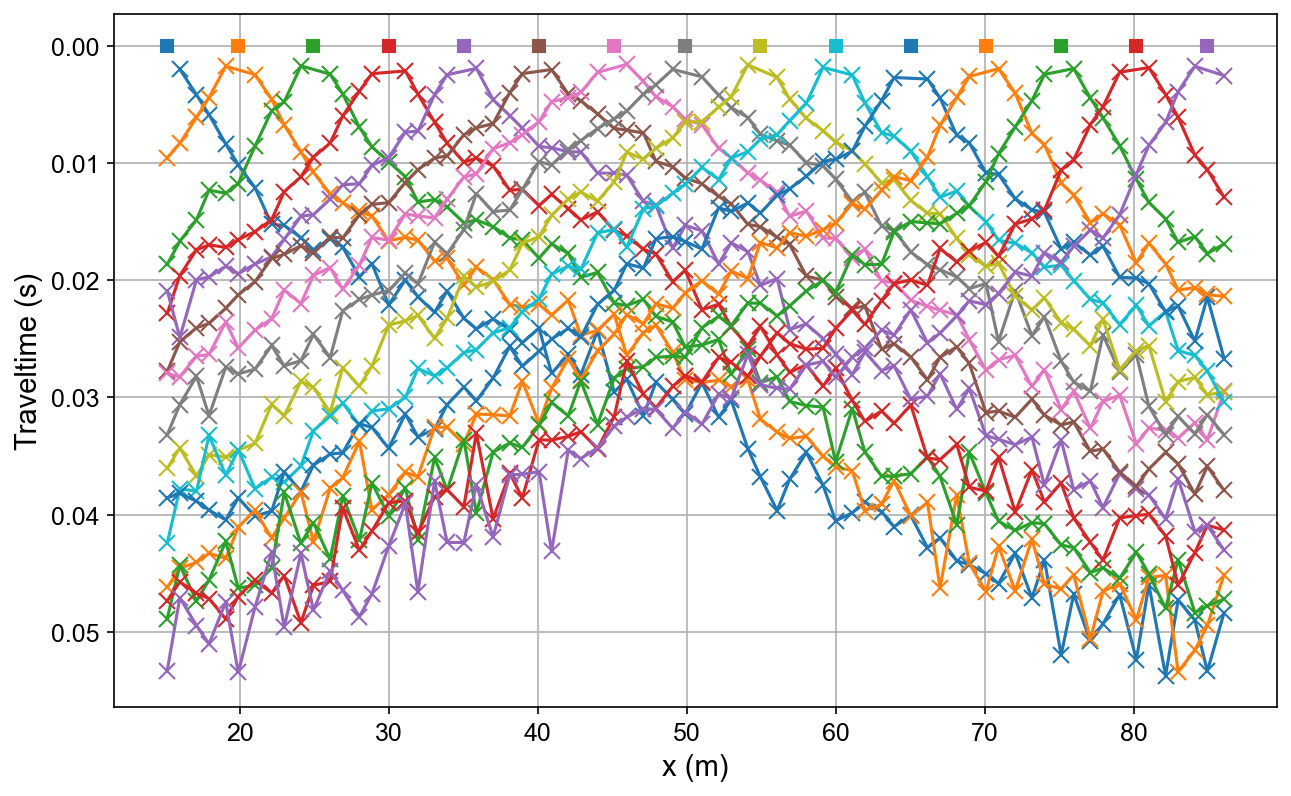

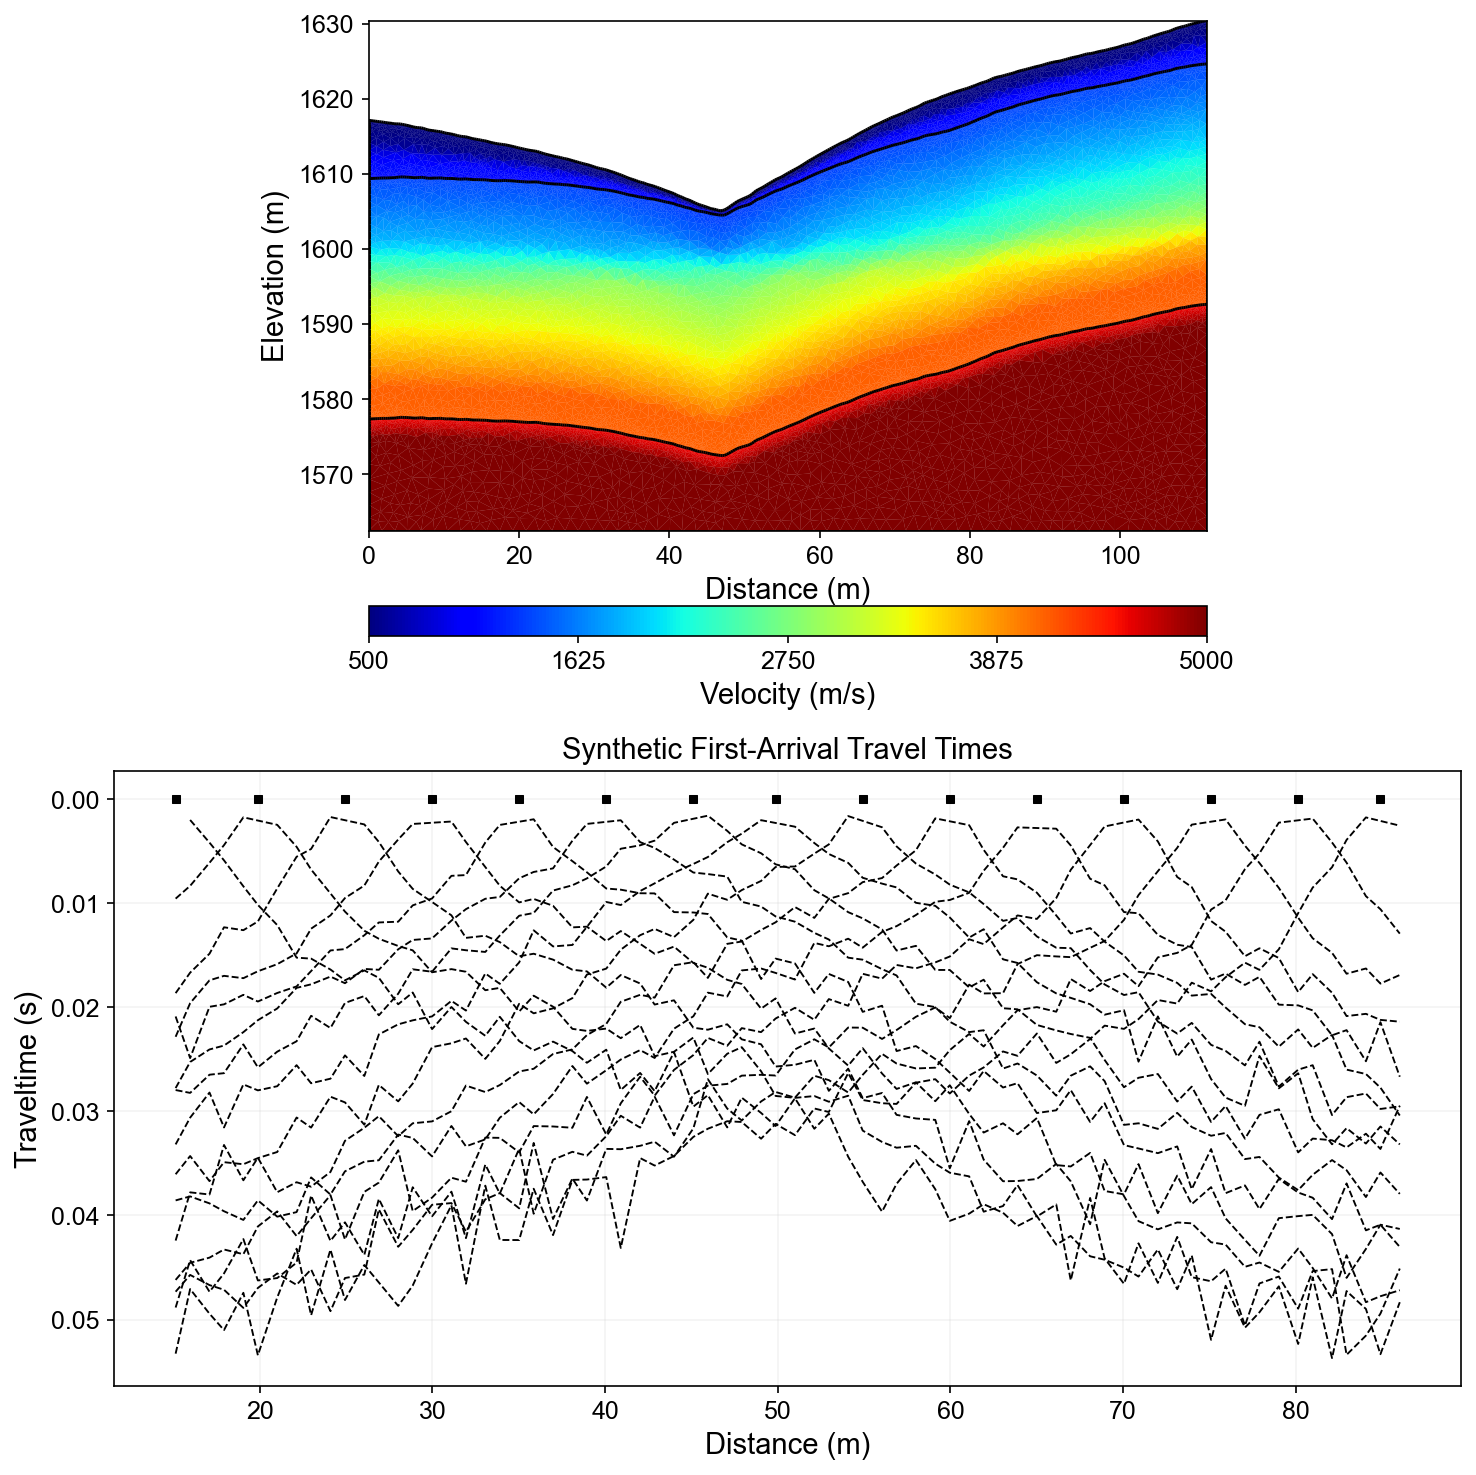

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg

# Import PyHydroGeophysX modules
from PyHydroGeophysX.core.interpolation import ProfileInterpolator, create_surface_lines
from PyHydroGeophysX.core.mesh_utils import MeshCreator
from PyHydroGeophysX.Hydro_modular.hydro_to_srt import hydro_to_srt

# 1. Set up output directory
output_dir = "results/srt_example"
os.makedirs(output_dir, exist_ok=True)

# Load your data
data_dir = "data/"
idomain = np.loadtxt(os.path.join(data_dir, "id.txt"))
top = np.loadtxt(os.path.join(data_dir, "top.txt"))
porosity = np.load(os.path.join(data_dir, "Porosity.npy"))
water_content = np.load(os.path.join(data_dir, "Watercontent.npy"))[5]  # Time step 50

# Set up profile
point1 = [115, 70]  
point2 = [95, 180]  

interpolator = ProfileInterpolator(
    point1=point1,
    point2=point2,
    surface_data=top,
    origin_x=569156.0,
    origin_y=4842444.0,
    pixel_width=1.0,
    pixel_height=-1.0,
    num_points=400
)

# Create mesh structure
bot = np.load(os.path.join(data_dir, "bot.npy"))
layer_idx = [0, 4, 12]  # Example indices for top, middle, and bottom layers
structure = interpolator.interpolate_layer_data([top] + bot.tolist())
surface, line1, line2 = create_surface_lines(
    L_profile=interpolator.L_profile,
    structure=structure,
    top_idx=layer_idx[0],
    mid_idx=layer_idx[1],
    bot_idx=layer_idx[2]
)

# Create mesh
mesh_creator = MeshCreator(quality=32)
mesh, geom = mesh_creator.create_from_layers(
    surface=surface,
    layers=[line1, line2],
    bottom_depth=np.min(line2[:,1])-10
)

# Define layer markers
marker_labels = [0, 3, 2]  # top, middle, bottom layers

# Rock physics parameters for each layer
vel_parameters = {
    'top': {
        'bulk_modulus': 30.0,         # GPa
        'shear_modulus': 20.0,        # GPa
        'mineral_density': 2650,      # kg/m³
        'depth': 1.0                  # m
    },
    'mid': {
        'bulk_modulus': 50.0,         # GPa
        'shear_modulus': 35.0,        # GPa
        'mineral_density': 2670,      # kg/m³
        'aspect_ratio': 0.05          # Crack aspect ratio
    },
    'bot': {
        'bulk_modulus': 55.0,         # GPa
        'shear_modulus': 50.0,        # GPa
        'mineral_density': 2680,      # kg/m³
        'aspect_ratio': 0.03          # Crack aspect ratio
    }
}
mesh_markers = np.array(mesh.cellMarkers())
# 13. Now we call hydro_to_srt with the pre-processed mesh values
synth_data, velocity_mesh = hydro_to_srt(
    water_content=water_content,           # Use pre-interpolated mesh values
    porosity=porosity,          # Use pre-interpolated mesh values
    mesh=mesh,
    profile_interpolator=interpolator,
    layer_idx=layer_idx,
    structure = structure,
    marker_labels=marker_labels,
    vel_parameters=vel_parameters,
    sensor_spacing=1.0,              
    sensor_start=15.0,               
    num_sensors=72,                  
    shot_distance=5,                 
    noise_level=0.05,                
    noise_abs=0.00001,               
    save_path=os.path.join(output_dir, "synthetic_seismic_data.dat"),
    mesh_markers=mesh_markers,       # Pass the mesh markers directly
    verbose=True,
    seed=1334                        
)

# 14. Visualize the results
from PyHydroGeophysX.forward.srt_forward import SeismicForwardModeling

# Create a figure
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Plot velocity model
pg.show(mesh, velocity_mesh, ax=axes[0], cMap='jet', 
        cMin=500, cMax=5000, label='Velocity (m/s)',
        xlabel="Distance (m)", ylabel="Elevation (m)")

# Plot first-arrival travel times
SeismicForwardModeling.draw_first_picks(axes[1], synth_data)
axes[1].set_title('Synthetic First-Arrival Travel Times')

plt.tight_layout()
